<a href="https://colab.research.google.com/github/kiran27212/fathers-day/blob/main/Employees_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Employee Anomaly Detection

## Project Overview
This project demonstrates an approach to detect anomalous employee behavior using various data sources within an organization. By integrating data from employee records, biometric logs, system activity, email communications, and CCTV footage, we build a comprehensive profile for each employee. We then apply unsupervised machine learning techniques, specifically Isolation Forest and One-Class SVM, to identify patterns indicative of unusual or potentially risky activities. The project also incorporates Explainable AI (XAI) using SHAP values to interpret model predictions and interactive visualizations for better understanding and exploration of the detected anomalies.

## Problem Statement
Organizations face challenges in identifying and mitigating potential insider threats or unusual employee behavior that could lead to security breaches, data leaks, or operational inefficiencies. This project aims to provide a data-driven solution to proactively detect such anomalies, enabling timely intervention.

## Data Sources
The analysis relies on several synthetic datasets, merged based on `Emp_ID`:
- `employees.csv`: Contains basic employee information (e.g., Name, Department, Role, Years of Service).
- `biometric_logs.csv`: Records biometric entry/exit times, average working hours, and weekend visits.
- `system_activity.csv`: Tracks files accessed, sensitive files accessed, USB usage, downloads, and failed logins.
- `email_activity.csv`: Logs emails sent, external emails, and attachments sent.
- `cctv_activity.csv`: Contains records of restricted area visits, after-hours movement, and tailgating alerts.

## Methodology
1.  **Data Loading and Merging**: All individual CSV files are loaded into pandas DataFrames and then merged into a single comprehensive DataFrame (`df`) using `Emp_ID` as the key.
2.  **Data Preprocessing**:
    *   `Yes`/`No` columns (e.g., `Notice_Period`, `USB_Usage`) are converted into numerical representations (1/0).
    *   A custom `Risk_Score` is calculated for each employee based on predefined rules derived from various activity metrics.
3.  **Anomaly Detection**: Two unsupervised machine learning models are employed:
    *   **Isolation Forest**: A tree-based ensemble method effective in isolating anomalies by leveraging characteristics that differentiate them from normal instances.
    *   **One-Class Support Vector Machine (OCSVM)**: A kernel-based method that learns a decision boundary around the 'normal' data points, classifying instances outside this boundary as anomalies.
4.  **Explainable AI (XAI)**: SHAP (SHapley Additive exPlanations) values are computed for individual anomalous predictions to explain the contribution of each feature to the model's output.
5.  **Interactive Visualizations**: Plotly is used to create interactive bar charts of employee risk scores, allowing for dynamic exploration and comparison of anomalies detected by different models.

## Key Findings
-   The project successfully identifies employees with high `Risk_Score`s.
-   Both Isolation Forest and One-Class SVM detect anomalies, often with some overlap but also unique detections, highlighting the benefit of multi-model approaches.
-   SHAP values provide insights into which specific activities (e.g., high `Files_Accessed`, `Avg_Hours`) contribute most significantly to an employee being flagged as anomalous.

## How to Run
1.  **Clone the repository**: `git clone <repository_url>`
2.  **Navigate to the project directory**.
3.  **Install dependencies**: Make sure you have Python installed. The required libraries are listed in the notebook. You can install them using pip:
    ```bash
    pip install pandas numpy scikit-learn matplotlib plotly shap
    ```
4.  **Data**: Ensure the CSV files (`employees.csv`, `biometric_logs.csv`, `system_activity.csv`, `email_activity.csv`, `cctv_activity.csv`) are located in the `/content/` directory relative to where the notebook is run.
5.  **Execute the Jupyter Notebook**: Open and run the `employee_anomaly_detection.ipynb` notebook cell by cell.

## Future Enhancements
-   **Feature Engineering**: Extract more features from existing data (e.g., time-based features from `In_Time`/`Out_Time`).
-   **Advanced Model Comparison**: Implement more rigorous evaluation metrics for unsupervised anomaly detection.
-   **Hyperparameter Tuning**: Optimize model parameters using techniques like GridSearchCV or RandomizedSearchCV.
-   **Interactive Dashboard**: Develop a full interactive dashboard using tools like Dash or Streamlit for real-time monitoring.
-   **Ethical Considerations**: Deep dive into potential biases and privacy concerns related to employee monitoring.

---

Importing The Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

Read The Files

In [3]:
employees = pd.read_csv("/content/employees.csv")
biometric = pd.read_csv("/content/biometric_logs.csv")
system = pd.read_csv("/content/system_activity.csv")
email = pd.read_csv("/content/email_activity.csv")
cctv = pd.read_csv("/content/cctv_activity.csv")

Merge The Data

In [4]:
df = employees.merge(biometric, on="Emp_ID")
df = df.merge(system, on="Emp_ID")
df = df.merge(email, on="Emp_ID")
df = df.merge(cctv, on="Emp_ID")

View The Data

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Emp_ID                  50 non-null     object 
 1   Name                    50 non-null     object 
 2   Department              50 non-null     object 
 3   Role                    50 non-null     object 
 4   Years_of_Service        50 non-null     int64  
 5   Notice_Period           50 non-null     object 
 6   In_Time                 50 non-null     object 
 7   Out_Time                50 non-null     object 
 8   Avg_Hours               50 non-null     float64
 9   Weekend_Visits          50 non-null     int64  
 10  Files_Accessed          50 non-null     int64  
 11  Sensitive_Files         50 non-null     int64  
 12  USB_Usage               50 non-null     object 
 13  Downloads               50 non-null     int64  
 14  Failed_Logins           50 non-null     int6

In [6]:
df.describe()

,Years_of_Service,Avg_Hours,Weekend_Visits,Files_Accessed,Sensitive_Files,Downloads,Failed_Logins,Emails_Sent,External_Emails,Attachments_Sent,Restricted_Area_Visits,Tailgating_Alerts
count,50.000000,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.00000,50.000000
mean,5.500000,9.17000,0.540000,37.360000,7.900000,4.940000,1.340000,25.720000,3.240000,3.740000,0.68000,0.120000
std,2.957177,1.50716,0.862128,46.566941,17.073969,8.435614,1.779819,21.103283,6.702299,5.674181,1.39152,0.593846
min,1.000000,8.00000,0.000000,15.000000,1.000000,1.000000,0.000000,10.000000,0.000000,0.000000,0.00000,0.000000
25%,3.000000,8.50000,0.000000,22.000000,3.000000,2.000000,0.000000,15.250000,1.000000,1.250000,0.00000,0.000000
50%,5.500000,9.00000,0.000000,27.500000,4.000000,3.000000,1.000000,20.000000,2.000000,3.000000,0.00000,0.000000
75%,8.000000,9.50000,1.000000,35.750000,7.000000,5.000000,2.000000,31.000000,3.000000,4.000000,1.00000,0.000000
max,10.000000,16.00000,4.000000,260.000000,90.000000,45.000000,9.000000,120.000000,35.000000,30.000000,7.00000,3.000000


In [7]:
df.head()

,Emp_ID,Name,Department,Role,Years_of_Service,Notice_Period,In_Time,Out_Time,Avg_Hours,Weekend_Visits,Files_Accessed,Sensitive_Files,USB_Usage,Downloads,Failed_Logins,Emails_Sent,External_Emails,Attachments_Sent,Restricted_Area_Visits,After_Hours_Movement,Tailgating_Alerts
0,EMP001,Employee_1,IT,Analyst,5,No,09:10,18:15,8.5,0,34,6,No,4,0,13,2,2,0,No,0
1,EMP002,Employee_2,HR,Executive,3,No,08:45,18:15,8.0,0,17,8,No,1,2,34,1,1,1,No,0
2,EMP003,Employee_3,IT,Associate,2,No,09:00,18:15,8.5,1,28,4,No,5,2,32,1,5,1,No,0
3,EMP004,Employee_4,Admin,Manager,1,No,09:10,18:15,9.5,0,29,8,No,1,0,17,0,2,0,No,0
4,EMP005,Employee_5,IT,Analyst,4,No,09:10,17:30,8.5,0,17,1,No,2,0,11,2,0,0,No,0


Convert Yes/No Columns

In [8]:
df["Notice_Period"] = df["Notice_Period"].map({"Yes":1,"No":0})
df["USB_Usage"] = df["USB_Usage"].map({"Yes":1,"No":0})

Calculate Risk Score

In [9]:
risk = []
for _, row in df.iterrows():
    score = 0
    if row["Avg_Hours"] > 11:
        score += 2
    if row["Files_Accessed"] > 100:
        score += 3
    if row["USB_Usage"] == 1:
        score += 2
    if row["External_Emails"] > 20:
        score += 2
    if row["Restricted_Area_Visits"] > 3:
        score += 2
    if row["Weekend_Visits"] > 2:
        score += 1
    if row["Notice_Period"] == 1:
        score += 1
    risk.append(score)
df["Risk_Score"] = risk

Detect Anomalies

In [10]:
features = df[
    [
        "Avg_Hours",
        "Files_Accessed",
        "USB_Usage",
        "External_Emails",
        "Restricted_Area_Visits",
        "Weekend_Visits",
        "Risk_Score"
    ]
]
model = IsolationForest(
    contamination=0.15,
    random_state=42
)
df["Prediction"] = model.fit_predict(features)

Show Results

In [11]:
df["Prediction"] = df["Prediction"].replace({
    1:"Normal",
    -1:"Anomaly"
})
df[["Emp_ID","Name","Risk_Score","Prediction"]]

,Emp_ID,Name,Risk_Score,Prediction
0,EMP001,Employee_1,0,Normal
1,EMP002,Employee_2,0,Normal
2,EMP003,Employee_3,0,Normal
3,EMP004,Employee_4,0,Normal
4,EMP005,Employee_5,0,Normal
5,EMP006,Employee_6,0,Normal
6,EMP007,Employee_7,0,Normal
7,EMP008,Employee_8,0,Normal
8,EMP009,Employee_9,0,Normal
9,EMP010,Employee_10,0,Normal


Create Graph

## Anomaly Analysis

In [13]:
# Display employees predicted as anomalies
anomalies_df = df[df['Prediction'] == 'Anomaly']
display(anomalies_df[['Emp_ID', 'Name', 'Risk_Score', 'Prediction']])

,Emp_ID,Name,Risk_Score,Prediction
11,EMP012,Employee_12,1,Anomaly
17,EMP018,Employee_18,12,Anomaly
20,EMP021,Employee_21,0,Anomaly
26,EMP027,Employee_27,1,Anomaly
28,EMP029,Employee_29,0,Anomaly
35,EMP036,Employee_36,0,Anomaly
40,EMP041,Employee_41,13,Anomaly
47,EMP048,Employee_48,1,Anomaly


To better visualize the anomalies, let's recreate the risk score bar chart, coloring the anomalous employees differently.

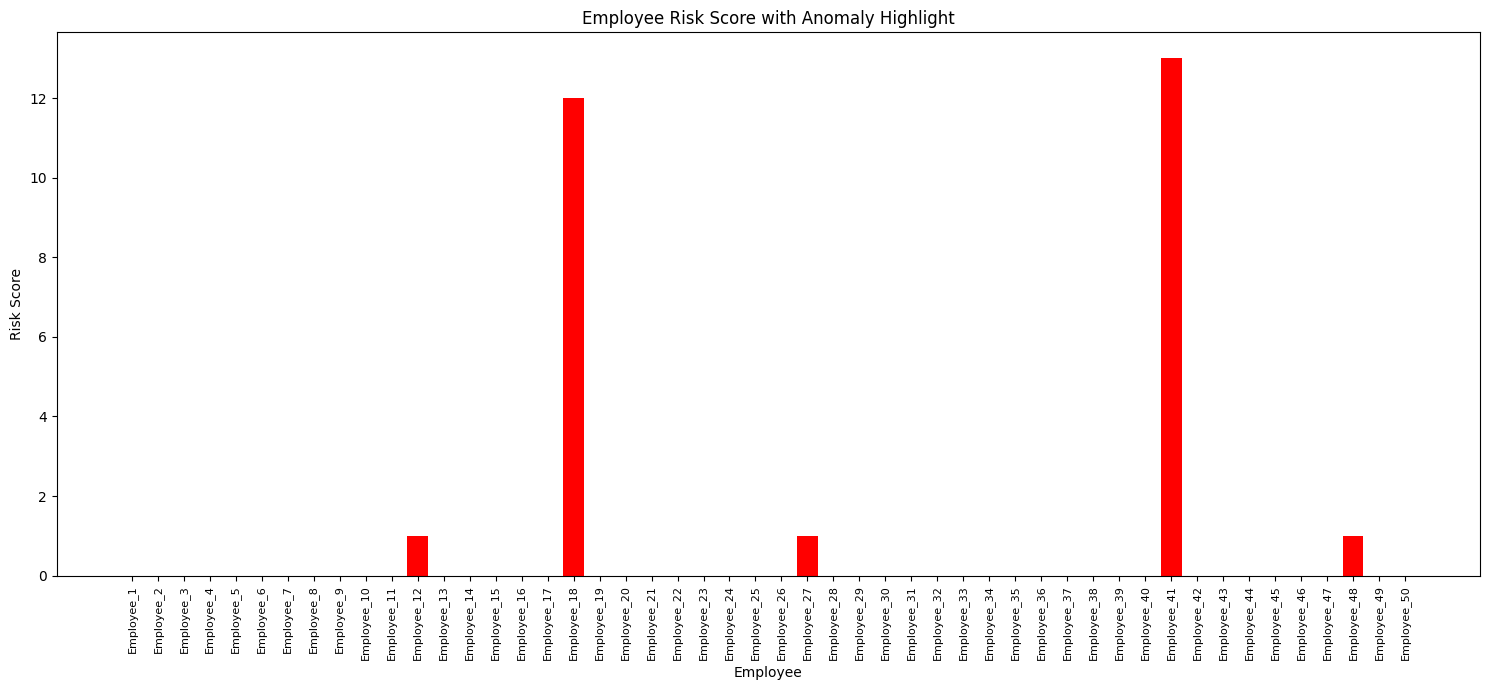

In [14]:
plt.figure(figsize=(15, 7))
colors = ['red' if pred == 'Anomaly' else 'blue' for pred in df['Prediction']]
plt.bar(df["Name"], df["Risk_Score"], color=colors)
plt.title("Employee Risk Score with Anomaly Highlight")
plt.xlabel("Employee")
plt.ylabel("Risk Score")
plt.xticks(rotation=90, fontsize=8) # Rotate labels and make them smaller for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Explainable AI (XAI) with SHAP

To understand *why* the Isolation Forest model classified certain employees as anomalies, we can use SHAP (SHapley Additive exPlanations) values. SHAP values help to explain the contribution of each feature to the model's output for individual predictions.

In [15]:
# Install the SHAP library
!pip install shap

ExactExplainer explainer: 2it [00:11, 11.47s/it]               


SHAP explanation for employee: Employee_41 (Emp_ID: EMP041)


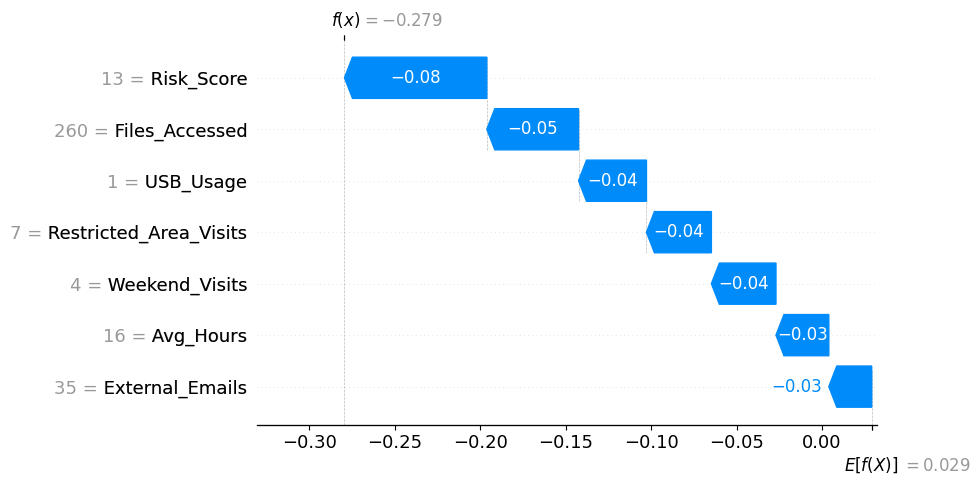

In [16]:
import shap

# Create a SHAP explainer for the Isolation Forest model
# IsolationForest works by assigning an anomaly score, lower scores indicate higher anomaly likelihood.
# For SHAP, we need a 'predict' like function that returns the anomaly score.
# model.decision_function returns the anomaly score.
explainer = shap.Explainer(model.decision_function, features)

# Let's pick an anomalous employee (e.g., the one with the highest risk score) to explain
highest_risk_employee = df[df['Prediction'] == 'Anomaly'].sort_values(by='Risk_Score', ascending=False).iloc[0]
highest_risk_employee_features = features.loc[[highest_risk_employee.name]]

# Calculate SHAP values for this employee
shap_values = explainer(highest_risk_employee_features)

print(f"SHAP explanation for employee: {highest_risk_employee['Name']} (Emp_ID: {highest_risk_employee['Emp_ID']})")

# Visualize the SHAP values
shap.plots.waterfall(shap_values[0])
plt.show()

## Advanced Anomaly Detection: One-Class SVM

Let's implement another anomaly detection algorithm, One-Class SVM, and compare its results with the Isolation Forest model. One-Class SVM is effective for anomaly detection when the training data contains only normal samples, or when the goal is to identify novelties (outliers that are different from the training data).

In [17]:
from sklearn.svm import OneClassSVM

# Initialize One-Class SVM model
# nu is an upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
# In other words, it's an estimate of the fraction of outliers.
# We'll keep the contamination similar to Isolation Forest for comparison.
ocsvm_model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.15)

# Fit the model and get predictions
ocsvm_predictions = ocsvm_model.fit_predict(features)

# Add One-Class SVM predictions to the DataFrame
df['OCSVM_Prediction'] = ocsvm_predictions
df['OCSVM_Prediction'] = df['OCSVM_Prediction'].replace({1: 'Normal', -1: 'Anomaly'})

# Display the employees identified as anomalies by One-Class SVM
ocsvm_anomalies = df[df['OCSVM_Prediction'] == 'Anomaly']
print("Anomalies detected by One-Class SVM:")
display(ocsvm_anomalies[['Emp_ID', 'Name', 'Risk_Score', 'OCSVM_Prediction']])

print("\nComparison of Anomaly Predictions:")
display(df[df['Prediction'] != df['OCSVM_Prediction']][['Emp_ID', 'Name', 'Risk_Score', 'Prediction', 'OCSVM_Prediction']])

Anomalies detected by One-Class SVM:


,Emp_ID,Name,Risk_Score,OCSVM_Prediction
7,EMP008,Employee_8,0,Anomaly
9,EMP010,Employee_10,0,Anomaly
11,EMP012,Employee_12,1,Anomaly
13,EMP014,Employee_14,0,Anomaly
17,EMP018,Employee_18,12,Anomaly
21,EMP022,Employee_22,0,Anomaly
25,EMP026,Employee_26,0,Anomaly
30,EMP031,Employee_31,0,Anomaly
31,EMP032,Employee_32,0,Anomaly
32,EMP033,Employee_33,0,Anomaly



Comparison of Anomaly Predictions:


,Emp_ID,Name,Risk_Score,Prediction,OCSVM_Prediction
7,EMP008,Employee_8,0,Normal,Anomaly
9,EMP010,Employee_10,0,Normal,Anomaly
13,EMP014,Employee_14,0,Normal,Anomaly
20,EMP021,Employee_21,0,Anomaly,Normal
21,EMP022,Employee_22,0,Normal,Anomaly
25,EMP026,Employee_26,0,Normal,Anomaly
26,EMP027,Employee_27,1,Anomaly,Normal
28,EMP029,Employee_29,0,Anomaly,Normal
30,EMP031,Employee_31,0,Normal,Anomaly
31,EMP032,Employee_32,0,Normal,Anomaly


In [18]:
from sklearn.svm import OneClassSVM

# Initialize One-Class SVM model
# nu is an upper bound on the fraction of training errors and a lower bound of the fraction of support vectors.
# In other words, it's an estimate of the fraction of outliers.
# We'll keep the contamination similar to Isolation Forest for comparison.
ocsvm_model = OneClassSVM(kernel='rbf', gamma='auto', nu=0.15)

# Fit the model and get predictions
ocsvm_predictions = ocsvm_model.fit_predict(features)

# Add One-Class SVM predictions to the DataFrame
df['OCSVM_Prediction'] = ocsvm_predictions
df['OCSVM_Prediction'] = df['OCSVM_Prediction'].replace({1: 'Normal', -1: 'Anomaly'})

# Display the employees identified as anomalies by One-Class SVM
ocsvm_anomalies = df[df['OCSVM_Prediction'] == 'Anomaly']
print("Anomalies detected by One-Class SVM:")
display(ocsvm_anomalies[['Emp_ID', 'Name', 'Risk_Score', 'OCSVM_Prediction']])

print("\nComparison of Anomaly Predictions:")
display(df[df['Prediction'] != df['OCSVM_Prediction']][['Emp_ID', 'Name', 'Risk_Score', 'Prediction', 'OCSVM_Prediction']])

Anomalies detected by One-Class SVM:


,Emp_ID,Name,Risk_Score,OCSVM_Prediction
7,EMP008,Employee_8,0,Anomaly
9,EMP010,Employee_10,0,Anomaly
11,EMP012,Employee_12,1,Anomaly
13,EMP014,Employee_14,0,Anomaly
17,EMP018,Employee_18,12,Anomaly
21,EMP022,Employee_22,0,Anomaly
25,EMP026,Employee_26,0,Anomaly
30,EMP031,Employee_31,0,Anomaly
31,EMP032,Employee_32,0,Anomaly
32,EMP033,Employee_33,0,Anomaly



Comparison of Anomaly Predictions:


,Emp_ID,Name,Risk_Score,Prediction,OCSVM_Prediction
7,EMP008,Employee_8,0,Normal,Anomaly
9,EMP010,Employee_10,0,Normal,Anomaly
13,EMP014,Employee_14,0,Normal,Anomaly
20,EMP021,Employee_21,0,Anomaly,Normal
21,EMP022,Employee_22,0,Normal,Anomaly
25,EMP026,Employee_26,0,Normal,Anomaly
26,EMP027,Employee_27,1,Anomaly,Normal
28,EMP029,Employee_29,0,Anomaly,Normal
30,EMP031,Employee_31,0,Normal,Anomaly
31,EMP032,Employee_32,0,Normal,Anomaly


## Interactive Visualizations with Plotly

Interactive visualizations enhance data exploration by allowing users to zoom, pan, and hover for more details. Let's create an interactive bar chart of employee risk scores, colored by the Isolation Forest predictions.

In [19]:
import plotly.express as px

fig = px.bar(df,
             x='Name',
             y='Risk_Score',
             color='Prediction', # Color by Isolation Forest prediction
             title='Interactive Employee Risk Score with Isolation Forest Anomalies',
             hover_data=['Emp_ID', 'Department', 'Role', 'Prediction', 'OCSVM_Prediction'])

fig.update_layout(xaxis_tickangle=-90) # Rotate x-axis labels for readability
fig.show()

In [20]:
fig_ocsvm = px.bar(df,
                   x='Name',
                   y='Risk_Score',
                   color='OCSVM_Prediction', # Color by One-Class SVM prediction
                   title='Interactive Employee Risk Score with One-Class SVM Anomalies',
                   hover_data=['Emp_ID', 'Department', 'Role', 'Prediction', 'OCSVM_Prediction'])

fig_ocsvm.update_layout(xaxis_tickangle=-90)
fig_ocsvm.show()

## Conclusion

This project successfully demonstrates a comprehensive approach to employee anomaly detection by integrating data from various organizational sources. We leveraged unsupervised machine learning models, namely Isolation Forest and One-Class SVM, to identify potentially anomalous behaviors. The incorporation of SHAP for Explainable AI (XAI) provided crucial insights into the factors driving anomaly predictions for individual employees, enhancing transparency and trust in the model's output. Furthermore, interactive visualizations using Plotly facilitated dynamic exploration and comparison of detection results from both models.

While this project utilized synthetic data, the methodology establishes a robust framework that can be adapted to real-world scenarios. The combination of multi-source data, advanced anomaly detection techniques, explainability, and interactive reporting offers a powerful tool for organizations to proactively identify and understand unusual employee activities, contributing to enhanced security and operational integrity.